# Andhra Pradesh OSM New Editor and First Changeset Discussion Analysis (2026)

This notebook uses the OSMCha API with the provided AOI filter and token to:
- fetch first changesets inside the selected Andhra Pradesh AOI
- inspect whether those first changesets received discussion comments
- plot the delay between changeset creation and first discussion comment

> Note: The AOI filter uses the OSMCha AOI endpoint. The OSMCha token is loaded from the environment variable `OSMCHA_TOKEN` so it is not stored in the notebook file. Discussion timestamps are retrieved from the OpenStreetMap changeset API.


In [1]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.style.use("seaborn-v0_8")

OSMCHA_TOKEN = os.environ.get("OSMCHA_TOKEN")
if not OSMCHA_TOKEN:
    raise EnvironmentError("OSMCHA_TOKEN environment variable is required")

OSMCHA_API_URL = "https://osmcha.org/api/v1"
AOI_ID = "05ef4393-c799-4d3e-aec1-25c317d0c79d"
OSM_API_URL = "https://api.openstreetmap.org/api/0.6"

session = requests.Session()
session.headers.update({
    "User-Agent": "copilot-osm-analysis/1.0",
    "Authorization": f"Token {OSMCHA_TOKEN}",
})


## Environment setup

This notebook reads the OSMCha token from the environment variable `OSMCHA_TOKEN` so that the secret is not committed to the repository.

To run this notebook in your shell, set the token first:
```bash
export OSMCHA_TOKEN=your_token_here
```

A sample `.env.example` file is included in the repository for reference.


In [2]:
def fetch_osmcha_aoi_changesets(aoi_id: str, page_size: int = 100) -> pd.DataFrame:
    url = f"{OSMCHA_API_URL}/aoi/{aoi_id}/changesets/"
    features = []
    page = 1
    while True:
        params = {"page": page, "page_size": page_size}
        response = session.get(url, params=params, timeout=120)
        response.raise_for_status()
        data = response.json()
        page_features = data.get("features", [])
        if not page_features:
            break
        features.extend(page_features)
        if not data.get("next"):
            break
        page += 1
        time.sleep(0.5)
    if not features:
        return pd.DataFrame()
    return pd.json_normalize(features, sep="_")

def fetch_osm_changeset_with_discussion(changeset_id: int) -> dict:
    url = f"{OSM_API_URL}/changeset/{changeset_id}.json"
    response = requests.get(url, params={"include_discussion": "true"}, headers={"User-Agent": "copilot-osm-analysis/1.0"}, timeout=120)
    response.raise_for_status()
    return response.json()

def get_first_discussion_datetime(changeset_json: dict):
    comments = changeset_json.get("changeset", {}).get("comments", [])
    if not comments:
        return None
    dates = [pd.to_datetime(c["date"]) for c in comments if c.get("date")]
    return min(dates) if dates else None


In [3]:
# Step 1: Fetch changesets from the provided OSMCha AOI filter
osmcha_changesets = fetch_osmcha_aoi_changesets(AOI_ID, page_size=100)
print(f"Fetched {len(osmcha_changesets)} Osmcha changeset features for AOI {AOI_ID}")
osmcha_changesets.head()


Fetched 16 Osmcha changeset features for AOI 05ef4393-c799-4d3e-aec1-25c317d0c79d


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_phone,properties_tag_changes_state,properties_tag_changes_mobile,properties_tag_changes_website,properties_tag_changes_landmark,properties_tag_changes_addr:full,properties_tag_changes_opening_hours,properties_metadata_resolved:outdated_tags:incomplete_tags,properties_metadata_highway,properties_tag_changes_man_made
0,182153379,Feature,Polygon,"[[[79.3480508, 13.6887455], [79.3487763, 13.68...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Srinu12345,24096424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,182155141,Feature,Polygon,"[[[80.6785149, 16.5224841], [80.6786588, 16.52...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Amman____,24096623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,182233665,Feature,Polygon,"[[[80.7052851, 16.5082794], [80.7053983, 16.50...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],2kcarcarevijayawada,24011551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,182433071,Feature,Polygon,"[[[82.2368683, 16.9914222], [82.2370554, 16.99...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],firefox321,24114183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,182558068,Feature,Polygon,"[[[81.837379, 17.0433619], [81.8391806, 17.043...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],imranv1,24121715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
osmcha_changesets["properties_date"] = pd.to_datetime(osmcha_changesets["properties_date"])
osmcha_changesets["first_month"] = osmcha_changesets["properties_date"].dt.to_period("M").astype(str)
osmcha_changesets["discussion_status"] = osmcha_changesets["properties_comments_count"].apply(lambda x: "has_comments" if x > 0 else "no_comments")

monthly_summary = osmcha_changesets.groupby("first_month").size().reset_index(name="first_changeset_editors")
monthly_summary


/tmp/ipykernel_64619/1585405128.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  osmcha_changesets["first_month"] = osmcha_changesets["properties_date"].dt.to_period("M").astype(str)


,first_month,first_changeset_editors
0,2026-05,11
1,2026-06,5


In [5]:
# Step 2: Inspect discussion timestamps for first changesets with comments
commented_first_cs = osmcha_changesets[osmcha_changesets["properties_comments_count"] > 0].copy()
print(f"Attempting to inspect discussion for {len(commented_first_cs)} first changesets")

first_comment_datetimes = []
for changeset_id in commented_first_cs["id"]:
    try:
        cs_json = fetch_osm_changeset_with_discussion(changeset_id)
        first_comment_datetimes.append(get_first_discussion_datetime(cs_json))
    except Exception as exc:
        print(f"Failed to fetch discussion for changeset {changeset_id}: {exc}")
        first_comment_datetimes.append(None)
    time.sleep(1)

commented_first_cs["first_comment_datetime"] = first_comment_datetimes
commented_first_cs["discussion_delay_hours"] = (commented_first_cs["first_comment_datetime"] - commented_first_cs["properties_date"]).dt.total_seconds() / 3600.0
commented_first_cs.head()


Attempting to inspect discussion for 16 first changesets


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_landmark,properties_tag_changes_addr:full,properties_tag_changes_opening_hours,properties_metadata_resolved:outdated_tags:incomplete_tags,properties_metadata_highway,properties_tag_changes_man_made,first_month,discussion_status,first_comment_datetime,discussion_delay_hours
0,182153379,Feature,Polygon,"[[[79.3480508, 13.6887455], [79.3487763, 13.68...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Srinu12345,24096424,...,NaN,NaN,NaN,NaN,NaN,NaN,2026-05,has_comments,2026-05-18 23:53:49+00:00,373.051944
1,182155141,Feature,Polygon,"[[[80.6785149, 16.5224841], [80.6786588, 16.52...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Amman____,24096623,...,NaN,NaN,NaN,NaN,NaN,NaN,2026-05,has_comments,2026-05-18 23:55:30+00:00,372.327222
2,182233665,Feature,Polygon,"[[[80.7052851, 16.5082794], [80.7053983, 16.50...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],2kcarcarevijayawada,24011551,...,NaN,NaN,NaN,NaN,NaN,NaN,2026-05,has_comments,2026-05-19 00:06:49+00:00,329.778056
3,182433071,Feature,Polygon,"[[[82.2368683, 16.9914222], [82.2370554, 16.99...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],firefox321,24114183,...,NaN,NaN,NaN,NaN,NaN,NaN,2026-05,has_comments,2026-05-19 00:08:35+00:00,223.571111
4,182558068,Feature,Polygon,"[[[81.837379, 17.0433619], [81.8391806, 17.043...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],imranv1,24121715,...,NaN,NaN,NaN,NaN,NaN,NaN,2026-05,has_comments,2026-05-19 00:09:00+00:00,153.931667


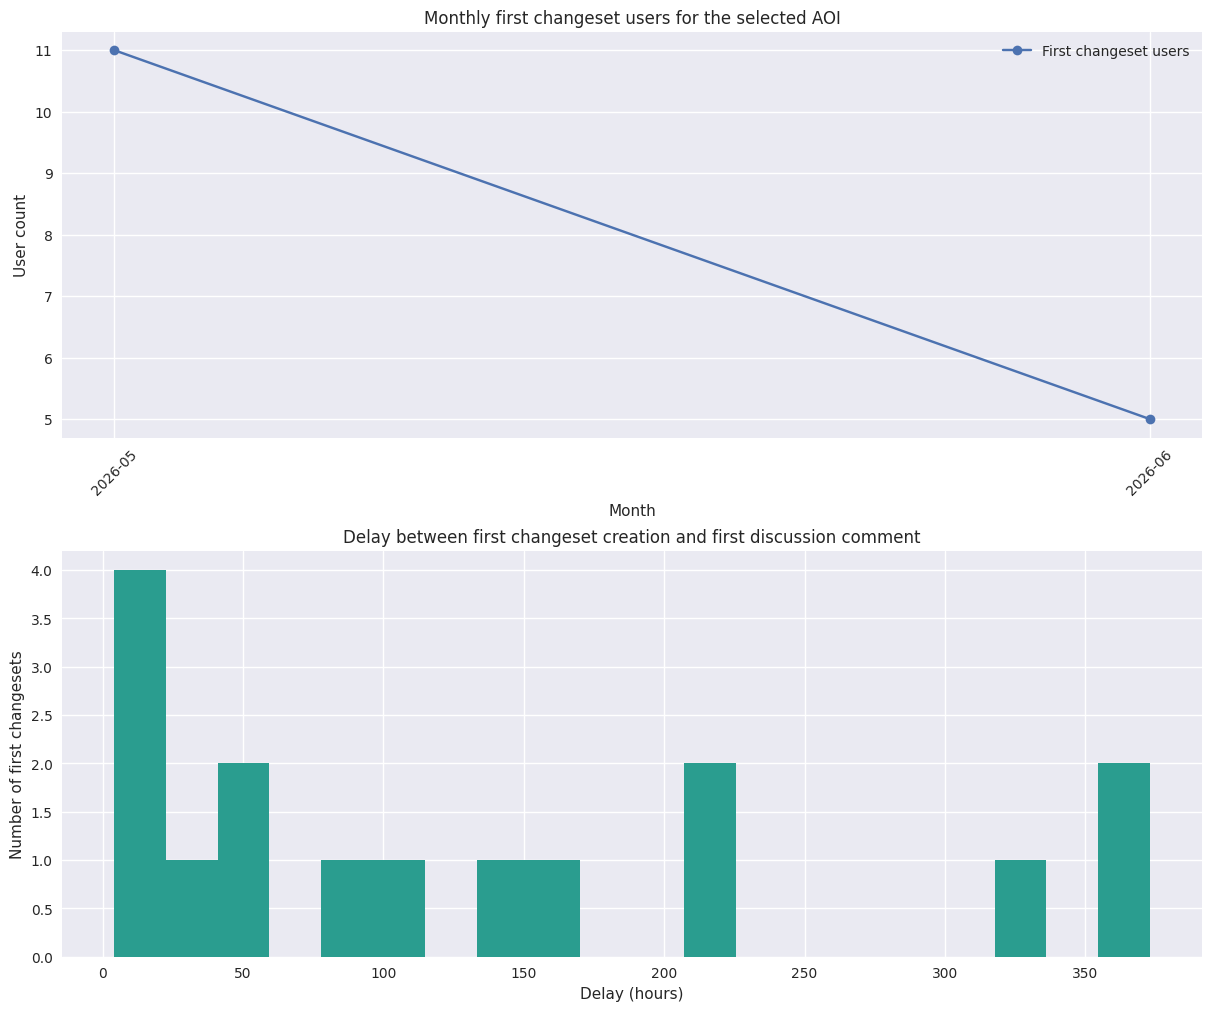

In [6]:
# Step 3: Plot monthly counts and discussion delay distribution
fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(monthly_summary["first_month"], monthly_summary["first_changeset_editors"], marker="o", label="First changeset users")
axes[0].set_title("Monthly first changeset users for the selected AOI")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("User count")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(commented_first_cs["discussion_delay_hours"].dropna(), bins=20, color="#2a9d8f")
axes[1].set_title("Delay between first changeset creation and first discussion comment")
axes[1].set_xlabel("Delay (hours)")
axes[1].set_ylabel("Number of first changesets")

plt.show()


## Limitations and notes
- The OSMCha AOI endpoint is used with the provided AOI ID and token.
- The token is loaded from the environment variable `OSMCHA_TOKEN` so it does not get saved in the notebook file.
- Discussion timestamps are retrieved from the OpenStreetMap changeset API using `include_discussion=true`.
- If the AOI contains many changesets, the API may paginate results; this notebook handles pagination for the OSMCha AOI changeset endpoint.
- OSM API discussion details may still require rate-limiting or caching for larger datasets.
